# Clase de Data Analytics: Ejercicios y CSV Sintético

Este notebook abarca varios ejercicios enfocados en análisis de datos y visualización. Se revisan conceptos como tasas de conversión, embudos de marketing y análisis de cohortes. Además, se generan archivos CSV sintéticos que servirán de fuente para los ejercicios prácticos. Cada sección incluye una breve explicación teórica y comentarios en el código para facilitar la comprensión.

## Generación de CSVs sintéticos

Antes de comenzar con los ejercicios, se generan datos sintéticos en varios archivos CSV que se almacenarán en la carpeta `datasets`. Estos datos simulan escenarios reales (como impresiones, clics, registros y eventos) y se utilizarán en los ejercicios posteriores para analizar embudos y cohortes.

In [1]:
import os
import pandas as pd
import numpy as np

# Crear la carpeta 'datasets' si no existe
os.makedirs("datasets", exist_ok=True)

# --- ad_data.csv ---
# Simula datos de publicidad: fecha, impresiones y clics
dates = pd.date_range(start="2022-01-01", periods=10, freq="D")
ad_data = pd.DataFrame({
    "date": dates.strftime("%Y-%m-%d"),
    "impressions": np.random.randint(1000, 5000, size=10),
    "clicks": np.random.randint(50, 300, size=10)
})
ad_data.to_csv("datasets/ad_data.csv", index=False)

# --- site_data.csv ---
# Simula datos del sitio: fecha y número de registros
site_data = pd.DataFrame({
    "date": dates.strftime("%Y-%m-%d"),
    "registrations": np.random.randint(10, 100, size=10)
})
site_data.to_csv("datasets/site_data.csv", index=False)

# --- funnel_daily.csv --- (14 días)
# Datos diarios para analizar embudos, con impresiones, clics y registros
dates_daily = pd.date_range(start="2022-01-01", periods=14, freq="D")
funnel_daily = pd.DataFrame({
    "date": dates_daily.strftime("%Y-%m-%d"),
    "impressions": np.random.randint(1000, 5000, size=14),
    "clicks": np.random.randint(50, 300, size=14),
    "registrations": np.random.randint(5, 100, size=14)
})
funnel_daily.to_csv("datasets/funnel_daily.csv", index=False)

# --- ad_data_2.csv ---
# Otro set de datos de publicidad para ejercicios adicionales
ad_data_2 = pd.DataFrame({
    "date": dates.strftime("%Y-%m-%d"),
    "impressions": np.random.randint(1000, 5000, size=10),
    "clicks": np.random.randint(50, 300, size=10)
})
ad_data_2.to_csv("datasets/ad_data_2.csv", index=False)

# --- site_data_2.csv ---
# Otro set de datos del sitio para ejercicios adicionales
site_data_2 = pd.DataFrame({
    "date": dates.strftime("%Y-%m-%d"),
    "registrations": np.random.randint(10, 100, size=10)
})
site_data_2.to_csv("datasets/site_data_2.csv", index=False)

# --- funnel_prod_events.csv ---
# Datos para analizar embudos de producto simples
funnel_prod_events = pd.DataFrame({
    "event_name": np.random.choice(["chat_message", "pageview", "success"], size=50),
    "uid": np.random.randint(100, 200, size=50)
})
funnel_prod_events.to_csv("datasets/funnel_prod_events.csv", index=False)

# --- events.csv ---
# Datos para secuencia de eventos en embudos de producto
uids = np.arange(1, 11)
records = []
for uid in uids:
    # Genera un tiempo base para cada usuario
    base_time = pd.Timestamp("2022-01-01 08:00:00") + pd.Timedelta(minutes=np.random.randint(0, 60))
    records.append({"uid": uid, "event_name": "pageview", "event_time": base_time})
    if np.random.rand() > 0.3:
        time_add = base_time + pd.Timedelta(minutes=5)
        records.append({"uid": uid, "event_name": "add_to_cart", "event_time": time_add})
    if np.random.rand() > 0.5:
        time_checkout = base_time + pd.Timedelta(minutes=10)
        records.append({"uid": uid, "event_name": "checkout", "event_time": time_checkout})
    if np.random.rand() > 0.7:
        time_payment = base_time + pd.Timedelta(minutes=15)
        records.append({"uid": uid, "event_name": "payment", "event_time": time_payment})
events_df = pd.DataFrame(records)
events_df.to_csv("datasets/events.csv", index=False)

# --- game_purchases.csv ---
# Datos de compras de juegos para análisis de cohortes
player_ids = np.arange(1, 21)
purchases_records = []
purchase_id = 1000
for player in player_ids:
    num_purchases = np.random.randint(1, 5)
    for i in range(num_purchases):
        purchase_datetime = pd.Timestamp("2022-01-01") + pd.Timedelta(days=np.random.randint(0, 60))
        price = np.round(np.random.uniform(0.99, 49.99), 2)
        purchases_records.append({
            "player_id": player,
            "purchase_datetime": purchase_datetime,
            "price": price,
            "purchase_id": purchase_id
        })
        purchase_id += 1
game_purchases = pd.DataFrame(purchases_records)
game_purchases.to_csv("datasets/game_purchases.csv", index=False)

# --- revenue_pivot.csv ---
# Datos para visualizar el tamaño promedio de compra en cohortes
revenue_pivot = pd.DataFrame({
    "first_order_month": ["2022-01", "2022-02", "2022-03"],
    "0": [50.5, 60.2, 70.1],
    "1": [45.3, 55.1, 65.4],
    "2": [40.0, 50.0, 60.0]
})
revenue_pivot.to_csv("datasets/revenue_pivot.csv", index=False)

# --- work_user_activity.csv ---
# Datos de actividad de usuario para analizar retención y churn
user_ids = np.arange(1, 11)
activity_records = []
for uid in user_ids:
    num_activities = np.random.randint(3, 10)
    start_date = pd.Timestamp("2022-01-01") + pd.Timedelta(days=np.random.randint(0, 10))
    for i in range(num_activities):
        activity_date = start_date + pd.Timedelta(days=np.random.randint(0, 30))
        activity_records.append({
            "user_id": uid,
            "activity_date": activity_date
        })
user_activity = pd.DataFrame(activity_records)
user_activity.to_csv("datasets/work_user_activity.csv", index=False)

# --- churn_rate.csv ---
# Datos para calcular la tasa de cancelación (churn rate)
churn_rate = pd.DataFrame({
    "first_event_week": ["2022-01-03", "2022-01-10", "2022-01-17"],
    "lifetime": [0, 1, 2],
    "users_count": [100, 80, 60]
})
churn_rate.to_csv("datasets/churn_rate.csv", index=False)

# --- coffee_home.csv ---
# Datos de consumo de café para análisis de cohortes comportamentales
coffee_records = []
for uid in np.arange(1, 11):
    first_coffee_datetime = pd.Timestamp("2022-01-01") + pd.Timedelta(days=np.random.randint(0, 5))
    num_coffees = np.random.randint(1, 8)
    for i in range(num_coffees):
        coffee_time = first_coffee_datetime + pd.Timedelta(days=np.random.randint(0, 30))
        coffee_records.append({
            "user_id": uid,
            "coffee_time": coffee_time,
            "first_coffee_datetime": first_coffee_datetime
        })
coffee_home = pd.DataFrame(coffee_records)
coffee_home.to_csv("datasets/coffee_home.csv", index=False)

print("CSV sintéticos generados en la carpeta 'datasets'")

CSV sintéticos generados en la carpeta 'datasets'


## Ejercicio 1: Tasa de conversión

### Concepto teórico:
La **tasa de conversión** es una métrica que permite medir el porcentaje de visitantes o usuarios que realizan una acción deseada (por ejemplo, una compra). Es fundamental en marketing digital para evaluar la eficacia de una campaña o la experiencia del usuario en una tienda.

### En este ejercicio:
Se muestran las tasas de conversión de dos tiendas (Store Sun y Store Moon) a lo largo de 10 días utilizando gráficos de línea, lo que permite comparar visualmente la evolución de las conversiones.

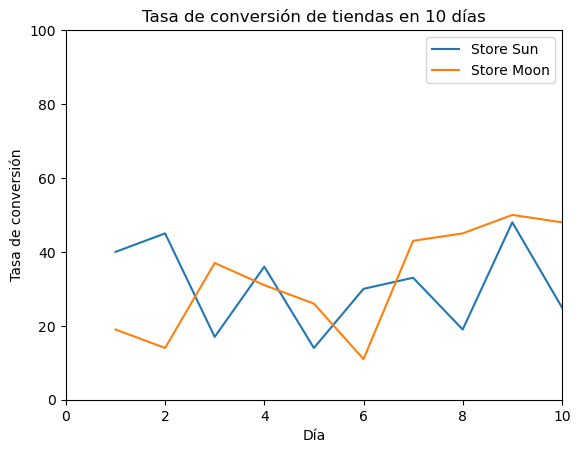

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definir días y tasas de conversión para cada tienda
days = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
store_sun = [40, 45, 17, 36, 14, 30, 33, 19, 48, 25]
store_moon = [19, 14, 37, 31, 26, 11, 43, 45, 50, 48]

# Crear el gráfico de líneas para cada tienda
ax = sns.lineplot(x=days, y=store_sun, label='Store Sun')
sns.lineplot(x=days, y=store_moon, label='Store Moon')

# Configurar etiquetas y título del gráfico
plt.xlabel('Día')  # Eje X: Días
plt.ylabel('Tasa de conversión')  # Eje Y: Tasa de conversión
plt.title('Tasa de conversión de tiendas en 10 días')

# Ajustar límites de los ejes para mejorar la visualización
ax.set_xlim(0, 10)
ax.set_ylim(0, 100)

# Mostrar la leyenda y el gráfico
plt.legend()
plt.show()

## Ejercicio 2: Embudos

### Concepto teórico:
Un **embudo de conversión** es una representación gráfica que muestra las diferentes etapas que atraviesa un usuario antes de completar una acción (por ejemplo, comprar un producto). Permite identificar en qué punto se pierden los usuarios y optimizar el proceso.

### En este ejercicio:
Se visualiza el embudo de compra de la tienda Store Sun utilizando un gráfico de barras sobre un fondo oscuro, mostrando las etapas del proceso (desde la página principal hasta el pedido).

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Datos para cada etapa del embudo de compra
data = {
    'Stage': ['Main page', 'Product page', 'Added to cart', 'Checkout page', 'Order'],
    'Quantity': [1525, 953, 595, 372, 232]
}

# Crear un DataFrame a partir de los datos
df = pd.DataFrame(data)

df.head()

,Stage,Quantity
0,Main page,1525
1,Product page,953
2,Added to cart,595
3,Checkout page,372
4,Order,232


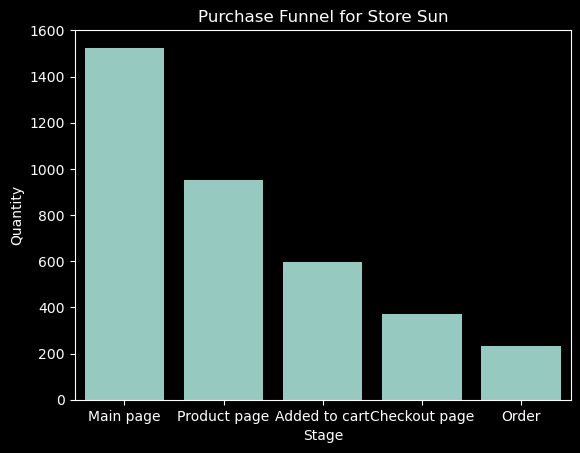

In [5]:
# Aplicar un estilo de fondo oscuro para el gráfico
plt.style.use("dark_background")

# Crear un gráfico de barras con los datos
sns.barplot(x='Stage', y='Quantity', data=df)

# Configurar etiquetas y título
plt.xlabel('Stage')
plt.ylabel('Quantity')
plt.title('Purchase Funnel for Store Sun')

# Mostrar el gráfico
plt.show()

## Ejercicio 3: Embudo de marketing (impresiones, clics, CTR y CR)

### Concepto teórico:
El análisis del embudo de marketing permite evaluar la eficiencia de una campaña publicitaria midiendo métricas como:
- **CTR (Click Through Rate):** Porcentaje de impresiones que generan clics.
- **CR (Conversion Rate):** Porcentaje de clics que se convierten en registros o ventas.

### En este ejercicio:
Se combinan dos fuentes de datos para calcular el CTR y CR, lo cual ayuda a identificar la efectividad de las campañas de publicidad y optimizar el embudo de marketing.

In [6]:
import pandas as pd

# Leer los datos de publicidad y sitio web
ad_data = pd.read_csv("datasets/ad_data.csv")
site_data = pd.read_csv("datasets/site_data.csv")


In [7]:
site_data

,date,registrations
0,2022-01-01,67
1,2022-01-02,92
2,2022-01-03,99
3,2022-01-04,46
4,2022-01-05,18
5,2022-01-06,74
6,2022-01-07,80
7,2022-01-08,43
8,2022-01-09,11
9,2022-01-10,92


In [8]:
# Combinar ambos datasets utilizando la columna 'date'
funnel = pd.merge(ad_data, site_data, on='date')

In [9]:
funnel.head()

,date,impressions,clicks,registrations
0,2022-01-01,4443,181,67
1,2022-01-02,3851,258,92
2,2022-01-03,2930,175,99
3,2022-01-04,4738,207,46
4,2022-01-05,4255,74,18


In [7]:
# Calcular CTR y CR
funnel['ctr, %'] = funnel['clicks'] / funnel['impressions'] * 100
funnel['cr, %'] = funnel['registrations'] / funnel['clicks'] * 100

# Mostrar las primeras filas del DataFrame resultante

funnel.head(10)

,date,impressions,clicks,registrations,"ctr, %","cr, %"
0,2022-01-01,3707,105,42,2.832479,40.000000
1,2022-01-02,4378,114,36,2.603929,31.578947
2,2022-01-03,3704,87,38,2.348812,43.678161
3,2022-01-04,1253,94,30,7.501995,31.914894
4,2022-01-05,3589,67,55,1.866815,82.089552
5,2022-01-06,3593,61,49,1.697746,80.327869
6,2022-01-07,3657,276,32,7.547170,11.594203
7,2022-01-08,4348,192,49,4.415823,25.520833
8,2022-01-09,2655,263,34,9.905838,12.927757
9,2022-01-10,2653,235,11,8.857897,4.680851


In [8]:
funnel.describe()

,impressions,clicks,registrations,"ctr, %","cr, %"
count,10.00000,10.000000,10.000000,10.000000,10.000000
mean,3353.70000,149.400000,37.600000,4.957850,36.431307
std,935.83463,83.577243,12.447222,3.166000,26.702492
min,1253.00000,61.000000,11.000000,1.697746,4.680851
25%,2888.50000,88.750000,32.500000,2.412591,16.076026
50%,3625.00000,109.500000,37.000000,3.624151,31.746920
75%,3706.25000,224.250000,47.250000,7.535876,42.758621
max,4378.00000,276.000000,55.000000,9.905838,82.089552


## Ejercicio 4: Embudo de marketing – Agrupación por semanas y meses

### Concepto teórico:
Agrupar datos por intervalos (semanas o meses) es fundamental para detectar tendencias a lo largo del tiempo. En el contexto de embudos de marketing, esto permite evaluar cómo varían las métricas (CTR y CR) en diferentes periodos y tomar decisiones basadas en patrones temporales.

### En este ejercicio:
Se agrupan los datos diarios para calcular métricas semanales y mensuales, facilitando el análisis de la evolución de las campañas publicitarias.

In [10]:
import pandas as pd

# Leer el archivo CSV con datos diarios
funnel_daily = pd.read_csv("datasets/funnel_daily.csv")

In [11]:
funnel_daily.head()

,date,impressions,clicks,registrations
0,2022-01-01,2504,277,21
1,2022-01-02,2675,287,91
2,2022-01-03,3685,157,25
3,2022-01-04,3117,205,9
4,2022-01-05,2071,145,17


In [14]:
funnel_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           14 non-null     object
 1   impressions    14 non-null     int64 
 2   clicks         14 non-null     int64 
 3   registrations  14 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 580.0+ bytes


In [13]:
# Convertir la columna 'date' a tipo datetime y extraer la semana
funnel_daily['date'] = pd.to_datetime(funnel_daily['date'])

In [14]:
funnel_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           14 non-null     datetime64[ns]
 1   impressions    14 non-null     int64         
 2   clicks         14 non-null     int64         
 3   registrations  14 non-null     int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 580.0 bytes


In [15]:
funnel_daily['week'] = funnel_daily['date'].dt.isocalendar().week
funnel_daily['year'] = funnel_daily['date'].dt.isocalendar().year

In [16]:
funnel_daily.head()

,date,impressions,clicks,registrations,week,year
0,2022-01-01,2504,277,21,52,2021
1,2022-01-02,2675,287,91,52,2021
2,2022-01-03,3685,157,25,1,2022
3,2022-01-04,3117,205,9,1,2022
4,2022-01-05,2071,145,17,1,2022


In [17]:
funnel_weekly = funnel_daily.groupby(['year','week'])[['impressions', 'clicks', 'registrations']].sum().reset_index()
funnel_weekly

,year,week,impressions,clicks,registrations
0,2021,52,5179,564,112
1,2022,1,17608,1303,241
2,2022,2,12314,777,324


In [20]:
# Agrupar por semana y sumar las métricas
funnel_weekly = funnel_daily.groupby('week')[['impressions', 'clicks', 'registrations']].sum()
funnel_weekly['ctr, %'] = (funnel_weekly['clicks'] / funnel_weekly['impressions'] * 100)
funnel_weekly['cr, %'] = (funnel_weekly['registrations'] / funnel_weekly['clicks'] * 100)
funnel_weekly

,impressions,clicks,registrations,"ctr, %","cr, %"
week,,,,,
1,21275,1403,342,6.594595,24.376336
2,14447,800,234,5.537482,29.250000
52,5376,294,89,5.468750,30.272109


In [18]:
# --- Otro ejercicio: embudos semanales, diarios y mensuales ---
# Leer otros conjuntos de datos para comparar
ad_data = pd.read_csv("datasets/ad_data_2.csv")
site_data = pd.read_csv("datasets/site_data_2.csv")

# Combinar ambos datasets
funnel_daily = pd.merge(ad_data, site_data, on='date')
funnel_daily['ctr, %'] = (funnel_daily['clicks'] / funnel_daily['impressions'] * 100)
funnel_daily['cr, %'] = (funnel_daily['registrations'] / funnel_daily['clicks'] * 100)

# Convertir fecha a datetime y extraer semana y mes
funnel_daily['date'] = pd.to_datetime(funnel_daily['date'])
funnel_daily['week'] = funnel_daily['date'].dt.isocalendar().week
funnel_daily['month'] = funnel_daily['date'].dt.month

# Agrupar por semana
funnel_weekly = funnel_daily.groupby('week')[['impressions', 'clicks', 'registrations']].sum()
funnel_weekly['ctr, %'] = (funnel_weekly['clicks'] / funnel_weekly['impressions'] * 100)
funnel_weekly['cr, %'] = (funnel_weekly['registrations'] / funnel_weekly['clicks'] * 100)

# Agrupar por mes
funnel_monthly = funnel_daily.groupby('month')[['impressions', 'clicks', 'registrations']].sum()
funnel_monthly['ctr, %'] = (funnel_monthly['clicks'] / funnel_monthly['impressions'] * 100)
funnel_monthly['cr, %'] = (funnel_monthly['registrations'] / funnel_monthly['clicks'] * 100)

print("Funnel Monthly:")
print(funnel_monthly)

Funnel Monthly:
       impressions  clicks  registrations    ctr, %      cr, %
month                                                         
1            31562    2150            646  6.811989  30.046512


## Ejercicio 5: Embudos de producto simples

### Concepto teórico:
El análisis de **embudos de producto** se centra en medir la interacción de los usuarios con distintos eventos de una aplicación o plataforma, identificando la cantidad de usuarios únicos en cada evento (por ejemplo, ver una página, enviar un mensaje o completar una acción exitosa).

### En este ejercicio:
Se calcula la cantidad de usuarios únicos por evento y se visualiza la actividad utilizando tanto agrupaciones numéricas como gráficos de línea.

In [22]:
import pandas as pd

# Leer el archivo CSV con eventos de producto
events = pd.read_csv("datasets/funnel_prod_events.csv")

# Agrupar los eventos por nombre y contar usuarios únicos
users_count = events.groupby('event_name').agg({'uid': 'nunique'}).sort_values(by='uid', ascending=False)
print(users_count)

              uid
event_name       
chat_message   18
pageview       16
success        14


<Axes: xlabel='event_name'>

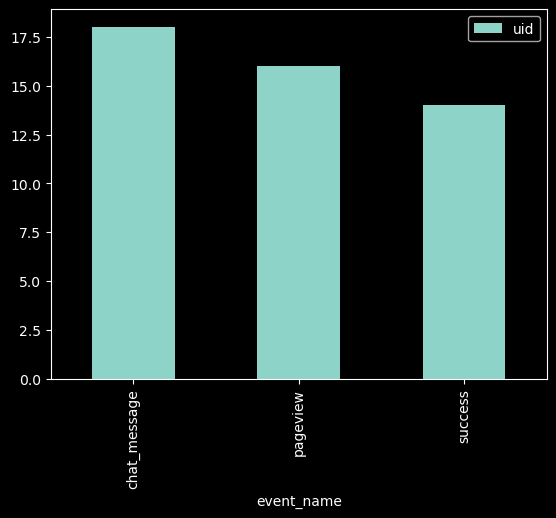

In [23]:
users_count.plot(kind='bar')

In [24]:
events.head()

,event_name,uid
0,pageview,160
1,chat_message,141
2,success,178
3,chat_message,138
4,chat_message,159


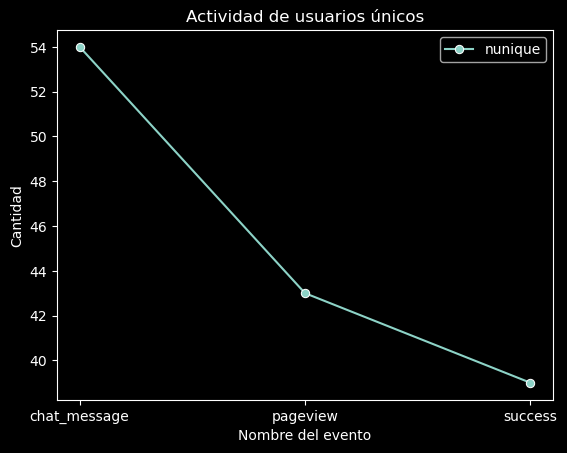

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un DataFrame con datos fijos para representar la actividad
data = pd.DataFrame({
    'event_name': ['chat_message', 'pageview', 'success'],
    'nunique': [54, 43, 39]
})

# Graficar la actividad de usuarios únicos
sns.lineplot(data=data, x='event_name', y='nunique', marker='o', label='nunique')

# Configurar etiquetas y título
plt.xlabel('Nombre del evento')
plt.ylabel('Cantidad')
plt.title('Actividad de usuarios únicos')

# Mostrar el gráfico
plt.show()

## Ejercicio 6: Embudos de productos con secuencia de eventos

### Concepto teórico:
Este ejercicio se centra en analizar la **secuencia de eventos** que siguen los usuarios dentro de una aplicación, desde la visualización de una página hasta completar una acción (por ejemplo, realizar un pago). El objetivo es determinar en qué pasos del embudo se pierde a la mayor parte de los usuarios y, por tanto, optimizar la experiencia del usuario.

### En este ejercicio:
Se utiliza una tabla pivote para obtener el primer registro de cada evento por usuario y se cuenta la cantidad de usuarios que completan cada paso del embudo.

In [26]:
import pandas as pd

# Leer el CSV con secuencia de eventos
events = pd.read_csv("datasets/events.csv")

# Crear una tabla pivote para obtener el primer evento de cada tipo por usuario
users = events.pivot_table(
    index='uid', 
    columns='event_name', 
    values='event_time',
    aggfunc='min'
)

# Contar cuántos usuarios tienen registrado el evento 'pageview'
pageview_count = users[~users['pageview'].isna()].shape[0]
print('Visitantes:', pageview_count)

Visitantes: 10


In [27]:
events.groupby('event_name')['event_time'].count().reset_index()

,event_name,event_time
0,add_to_cart,5
1,checkout,5
2,pageview,10
3,payment,2


In [28]:
events.head()

,uid,event_name,event_time
0,1,pageview,2022-01-01 08:36:00
1,1,add_to_cart,2022-01-01 08:41:00
2,2,pageview,2022-01-01 08:48:00
3,3,pageview,2022-01-01 08:49:00
4,3,checkout,2022-01-01 08:59:00


In [20]:
import pandas as pd

# Leer los datos nuevamente
events = pd.read_csv("datasets/events.csv")

# Crear la tabla pivote con el primer registro de cada evento
users = events.pivot_table(
    index='uid', 
    columns='event_name', 
    values='event_time',
    aggfunc='min'
)

In [21]:
users

event_name,add_to_cart,checkout,pageview,payment
uid,,,,
1,2022-01-01 08:10:00,NaN,2022-01-01 08:05:00,NaN
2,2022-01-01 08:31:00,2022-01-01 08:36:00,2022-01-01 08:26:00,NaN
3,NaN,2022-01-01 08:43:00,2022-01-01 08:33:00,2022-01-01 08:48:00
4,NaN,2022-01-01 08:10:00,2022-01-01 08:00:00,NaN
5,2022-01-01 08:53:00,2022-01-01 08:58:00,2022-01-01 08:48:00,2022-01-01 09:03:00
6,2022-01-01 08:12:00,NaN,2022-01-01 08:07:00,NaN
7,2022-01-01 08:18:00,2022-01-01 08:23:00,2022-01-01 08:13:00,NaN
8,2022-01-01 08:33:00,NaN,2022-01-01 08:28:00,NaN
9,2022-01-01 08:38:00,2022-01-01 08:43:00,2022-01-01 08:33:00,NaN


In [22]:
# Definir pasos del embudo: cada paso se valida que ocurra después del anterior
step_1 = users['pageview'].notnull()
step_2 = step_1 & (users['add_to_cart'] > users['pageview'])
step_3 = step_2 & (users['checkout'] > users['add_to_cart'])
step_4 = step_3 & (users['payment'] > users['checkout'])


In [23]:
step_4

uid
1     False
2     False
3     False
4     False
5      True
6     False
7     False
8     False
9     False
10    False
dtype: bool

In [24]:
# Calcular el número de usuarios en cada etapa
n_pageview = users[step_1].shape[0]
n_add_to_cart = users[step_2].shape[0]
n_checkout = users[step_3].shape[0]
n_payment = users[step_4].shape[0]

# Imprimir los resultados
print('Visitantes:', n_pageview)
print('Se agregó un producto al carrito:', n_add_to_cart)
print('Pago iniciado:', n_checkout)
print('Pagado:', n_payment)

Visitantes: 10
Se agregó un producto al carrito: 8
Pago iniciado: 5
Pagado: 1


## Segundo momento: Análisis de cohortes

El análisis de cohortes es una técnica que agrupa a los usuarios según un evento común (por ejemplo, la primera compra o actividad) para analizar su comportamiento a lo largo del tiempo. Esto permite identificar patrones de retención, abandono y evolución en el comportamiento de los usuarios.

En las siguientes secciones se abordarán diferentes aspectos del análisis de cohortes, desde la agrupación inicial hasta la visualización de la retención y la tasa de cancelación.

### Cohorte 1: Análisis de cohortes en Python

#### Concepto teórico:
En este ejercicio se agrupa a los usuarios por el mes de su primera compra. De esta manera, se puede analizar cuánto gasta cada cohorte de usuarios a lo largo del tiempo. Esto es útil para identificar qué cohortes tienen mayor valor a lo largo de su ciclo de vida.

#### En este ejercicio:
Se convierte la fecha a un período mensual y se agrupa el gasto total (price) por el primer mes de compra.

In [1]:
import pandas as pd

# Leer datos de compras de juegos
purchases = pd.read_csv("datasets/game_purchases.csv")

purchases.head()

,player_id,purchase_datetime,price,purchase_id
0,1,2022-02-24,27.71,1000
1,1,2022-01-06,23.36,1001
2,1,2022-01-05,48.19,1002
3,1,2022-02-02,4.67,1003
4,2,2022-02-08,2.49,1004


In [2]:
purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   player_id          45 non-null     int64  
 1   purchase_datetime  45 non-null     object 
 2   price              45 non-null     float64
 3   purchase_id        45 non-null     int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 1.5+ KB


In [3]:
# Calcular la fecha de la primera compra para cada jugador
first_purchase_dates = purchases.groupby('player_id')['purchase_datetime'].min()
first_purchase_dates.name = 'first_purchase_datetime'
purchases = purchases.join(first_purchase_dates, on='player_id')

In [4]:
first_purchase_dates.head()

player_id
1    2022-01-05
2    2022-02-08
3    2022-01-05
4    2022-01-06
5    2022-02-15
Name: first_purchase_datetime, dtype: object

In [38]:


# Convertir las fechas a períodos mensuales para agrupar por mes
purchases['purchase_month'] = pd.to_datetime(purchases['purchase_datetime']).dt.to_period('M')
purchases['first_purchase_month'] = pd.to_datetime(purchases['first_purchase_datetime']).dt.to_period('M')

# Agrupar por el primer mes de compra y sumar el gasto
cohort_stats = purchases.groupby('first_purchase_month')['price'].sum()
print(cohort_stats)

first_purchase_month
2022-01    844.23
2022-02    246.03
Freq: M, Name: price, dtype: float64


### Cohorte 2: Evaluación de cambios en los valores absolutos por mes

#### Concepto teórico:
Este análisis compara, para cada cohorte (definida por el mes de la primera compra), el número de compras y usuarios únicos en distintos meses, permitiendo calcular el promedio de compras por jugador. Esto ayuda a evaluar la fidelidad y actividad de cada cohorte a lo largo del tiempo.

#### En este ejercicio:
Se agrupan las compras por el mes de la primera compra y el mes de la compra, calculando el promedio de compras por jugador.

In [12]:
import pandas as pd

# Leer datos de compras
purchases = pd.read_csv("datasets/game_purchases.csv")

# Calcular la primera fecha de compra para cada jugador
first_purchase_dates = purchases.groupby('player_id')['purchase_datetime'].min()
first_purchase_dates.name = 'first_purchase_datetime'
purchases = purchases.join(first_purchase_dates, on='player_id')

In [14]:
purchases.head()

,player_id,purchase_datetime,price,purchase_id,first_purchase_datetime
0,1,2022-02-22,27.30,1000,2022-01-03
1,1,2022-01-03,29.88,1001,2022-01-03
2,1,2022-01-21,5.10,1002,2022-01-03
3,1,2022-03-01,41.78,1003,2022-01-03
4,2,2022-02-19,11.85,1004,2022-02-19


In [15]:
# Convertir las fechas a períodos mensuales
purchases['purchase_month'] = pd.to_datetime(purchases['purchase_datetime']).dt.to_period('M')
purchases['first_purchase_month'] = pd.to_datetime(purchases['first_purchase_datetime']).dt.to_period('M')

purchases.head()

,player_id,purchase_datetime,price,purchase_id,first_purchase_datetime,purchase_month,first_purchase_month
0,1,2022-02-22,27.30,1000,2022-01-03,2022-02,2022-01
1,1,2022-01-03,29.88,1001,2022-01-03,2022-01,2022-01
2,1,2022-01-21,5.10,1002,2022-01-03,2022-01,2022-01
3,1,2022-03-01,41.78,1003,2022-01-03,2022-03,2022-01
4,2,2022-02-19,11.85,1004,2022-02-19,2022-02,2022-02


In [16]:
# Agrupar por primer mes de compra y mes de compra para calcular métricas
purchases_grouped_by_cohorts = purchases.groupby(['first_purchase_month', 'purchase_month']).agg({
    'purchase_id': 'nunique',
    'player_id': 'nunique'
})

# Calcular el promedio de compras por jugador
purchases_grouped_by_cohorts['purchases_per_player'] = purchases_grouped_by_cohorts['purchase_id'] / purchases_grouped_by_cohorts['player_id']

# Crear una tabla pivote para visualizar la evolución de la métrica
mean_purchases_pivot = purchases_grouped_by_cohorts.pivot_table(
    index='first_purchase_month',
    columns='purchase_month',
    values='purchases_per_player',
    aggfunc='sum'
)
print(mean_purchases_pivot)

purchase_month         2022-01   2022-02  2022-03
first_purchase_month                             
2022-01               1.529412  1.615385      1.0
2022-02                    NaN  1.333333      NaN


### Cohorte 3: Evaluación de los cambios en los valores relativos por ciclo de vida

#### Concepto teórico:
Este ejercicio analiza la evolución del número de compras por jugador a lo largo del tiempo, desde su primera compra. La diferencia en meses entre el primer mes de compra y el mes actual se denomina "cohort lifetime" y permite medir cómo varía la actividad de la cohorte.

#### En este ejercicio:
Se calcula el ciclo de vida de la cohorte en meses y se genera una tabla pivote que muestra el promedio de compras por jugador a lo largo de este ciclo.

In [25]:
import pandas as pd
import numpy as np

# Leer datos de compras
purchases = pd.read_csv("datasets/game_purchases.csv")

purchases.head()

,player_id,purchase_datetime,price,purchase_id
0,1,2022-01-13,48.97,1000
1,1,2022-02-07,21.82,1001
2,1,2022-02-01,45.77,1002
3,1,2022-02-15,38.13,1003
4,2,2022-02-17,8.51,1004


In [26]:
# Calcular la primera fecha de compra para cada jugador
first_purchase_dates = purchases.groupby('player_id')['purchase_datetime'].min()
first_purchase_dates.head()

player_id
1    2022-01-13
2    2022-01-22
3    2022-01-15
4    2022-01-20
5    2022-01-12
Name: purchase_datetime, dtype: object

In [27]:
first_purchase_dates.name = 'first_purchase_datetime'
purchases = purchases.join(first_purchase_dates, on='player_id')

purchases.head()

,player_id,purchase_datetime,price,purchase_id,first_purchase_datetime
0,1,2022-01-13,48.97,1000,2022-01-13
1,1,2022-02-07,21.82,1001,2022-01-13
2,1,2022-02-01,45.77,1002,2022-01-13
3,1,2022-02-15,38.13,1003,2022-01-13
4,2,2022-02-17,8.51,1004,2022-01-22


In [30]:
# Convertir las fechas a períodos mensuales
purchases['purchase_month'] = pd.to_datetime(purchases['purchase_datetime']).dt.to_period('M') # dt.month. dt.year
purchases['first_purchase_month'] = pd.to_datetime(purchases['first_purchase_datetime']).dt.to_period('M')

purchases.head()

,player_id,purchase_datetime,price,purchase_id,first_purchase_datetime,purchase_month,first_purchase_month
0,1,2022-01-13,48.97,1000,2022-01-13,2022-01,2022-01
1,1,2022-02-07,21.82,1001,2022-01-13,2022-02,2022-01
2,1,2022-02-01,45.77,1002,2022-01-13,2022-02,2022-01
3,1,2022-02-15,38.13,1003,2022-01-13,2022-02,2022-01
4,2,2022-02-17,8.51,1004,2022-01-22,2022-02,2022-01


In [29]:
# Agrupar por primer mes y mes de compra
purchases_grouped_by_cohorts = purchases.groupby(['first_purchase_month', 'purchase_month']).agg({
    'purchase_id': 'nunique',
    'player_id': 'nunique'
})
purchases_grouped_by_cohorts.head()

purchase_id  player_id
first_purchase_month purchase_month                        
2022-01              2022-01                  29         19
                     2022-02                  26         15
2022-02              2022-02                   1          1

In [32]:
# Calcular el promedio de compras por jugador para cada cohorte
purchases_grouped_by_cohorts['purchases_per_player'] = purchases_grouped_by_cohorts['purchase_id'] / purchases_grouped_by_cohorts['player_id']

purchases_grouped_by_cohorts.head()

purchase_id  player_id  \
first_purchase_month purchase_month                           
2022-01              2022-01                  29         19   
                     2022-02                  26         15   
2022-02              2022-02                   1          1   

                                     purchases_per_player  
first_purchase_month purchase_month                        
2022-01              2022-01                     1.526316  
                     2022-02                     1.733333  
2022-02              2022-02                     1.000000

In [34]:
# Reiniciar el índice para facilitar los cálculos
purchases_grouped_by_cohorts = purchases_grouped_by_cohorts.reset_index()

purchases_grouped_by_cohorts.head()

,index,first_purchase_month,purchase_month,purchase_id,player_id,purchases_per_player
0,0,2022-01,2022-01,29,19,1.526316
1,1,2022-01,2022-02,26,15,1.733333
2,2,2022-02,2022-02,1,1,1.000000


In [35]:
# Calcular la diferencia en meses (cohort lifetime) usando la propiedad .n
purchases_grouped_by_cohorts['cohort_lifetime'] = (purchases_grouped_by_cohorts['purchase_month'] - purchases_grouped_by_cohorts['first_purchase_month']).apply(lambda x: x.n)

purchases_grouped_by_cohorts.head()

,index,first_purchase_month,purchase_month,purchase_id,player_id,purchases_per_player,cohort_lifetime
0,0,2022-01,2022-01,29,19,1.526316,0
1,1,2022-01,2022-02,26,15,1.733333,1
2,2,2022-02,2022-02,1,1,1.000000,0


In [36]:
# Crear una tabla pivote para visualizar la evolución de la actividad de la cohorte
lifetime_pivot = purchases_grouped_by_cohorts.pivot_table(
    index='first_purchase_month',
    columns='cohort_lifetime',
    values='purchases_per_player',
    aggfunc='sum'
)
print(lifetime_pivot)

cohort_lifetime              0         1
first_purchase_month                    
2022-01               1.526316  1.733333
2022-02               1.000000       NaN


### Cohorte 4: Visualización del análisis de cohortes

#### Concepto teórico:
La visualización mediante mapas de calor es una forma efectiva de representar la evolución de métricas en diferentes cohortes, facilitando la identificación de patrones y áreas de mejora.

#### En este ejercicio:
Se utiliza un mapa de calor para visualizar el tamaño promedio de compra del cliente a partir de la tabla pivot generada anteriormente.

In [23]:
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd

# Leer la tabla pivot generada previamente para visualizar cohortes
revenue_per_user_pivot = pd.read_csv("datasets/revenue_pivot.csv")
revenue_per_user_pivot = revenue_per_user_pivot.set_index('first_order_month')

In [24]:
revenue_per_user_pivot.head()

,0,1,2
first_order_month,,,
2022-01,50.5,45.3,40.0
2022-02,60.2,55.1,50.0
2022-03,70.1,65.4,60.0


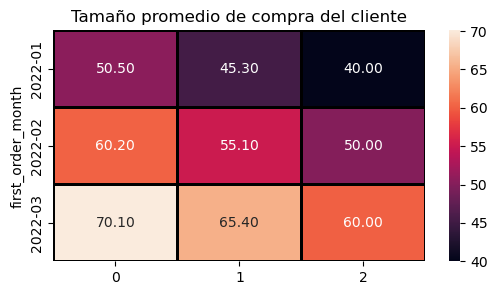

In [25]:


# Configurar la figura
plt.figure(figsize=(6, 3))
plt.title('Tamaño promedio de compra del cliente')

# Crear un mapa de calor con la tabla pivot
sns.heatmap(revenue_per_user_pivot, annot=True, fmt='.2f', linewidths=1, linecolor='black')

# Mostrar el gráfico
plt.show()

### Cohorte 5: Tasa de retención y de cancelación

#### Concepto teórico:
La **tasa de retención** mide el porcentaje de usuarios que continúan utilizando una aplicación o servicio en periodos sucesivos. La **tasa de cancelación** (churn rate) indica el porcentaje de usuarios que abandonan la plataforma. Estas métricas son fundamentales para evaluar la fidelidad del cliente y el éxito de estrategias de retención.

#### En este ejercicio:
Se prepara y transforma la información de actividad de usuario para calcular la retención y analizar la evolución de la actividad semanal.

In [40]:
import pandas as pd

# Leer datos de actividad de usuario
user_activity = pd.read_csv("datasets/work_user_activity.csv")

In [42]:
user_activity.head(20)

,user_id,activity_date
0,1,2022-02-01
1,1,2022-01-03
2,1,2022-01-28
3,2,2022-01-14
4,2,2022-01-20
5,2,2022-01-30
6,2,2022-02-01
7,2,2022-01-30
8,2,2022-01-30
9,2,2022-01-24


In [43]:
# Convertir la columna 'activity_date' a datetime
user_activity['activity_date'] = pd.to_datetime(user_activity['activity_date'])

# Calcular la primera actividad para cada usuario
first_activity_date = user_activity.groupby(['user_id'])['activity_date'].min()
first_activity_date.name = 'first_activity_date'
user_activity = user_activity.join(first_activity_date, on='user_id')

# Calcular el inicio de la semana para cada fecha de actividad
user_activity['activity_week'] = pd.to_datetime(user_activity['activity_date']) - pd.to_timedelta(user_activity['activity_date'].dt.dayofweek, unit='d')
user_activity['first_activity_week'] = pd.to_datetime(user_activity['first_activity_date']) - pd.to_timedelta(user_activity['first_activity_date'].dt.dayofweek, unit='d')

# Mostrar las primeras filas para ver la estructura
user_activity.head()

,user_id,activity_date,first_activity_date,activity_week,first_activity_week
0,1,2022-02-01,2022-01-03,2022-01-31,2022-01-03
1,1,2022-01-03,2022-01-03,2022-01-03,2022-01-03
2,1,2022-01-28,2022-01-03,2022-01-24,2022-01-03
3,2,2022-01-14,2022-01-09,2022-01-10,2022-01-03
4,2,2022-01-20,2022-01-09,2022-01-17,2022-01-03


### Cohorte 6: Cálculo de las tasas de retención en Python

#### Concepto teórico:
El cálculo de la retención por cohorte permite evaluar cuántos usuarios continúan activos en periodos posteriores a su primera actividad. Esto se suele representar en una tabla dinámica donde cada columna indica el tiempo transcurrido desde la primera actividad.

#### En este ejercicio:
Se calcula el ciclo de vida de cada cohorte en semanas y se genera una tabla pivote que muestra la retención de usuarios.

In [50]:
import pandas as pd
import numpy as np

# Leer datos de actividad de usuario
user_activity = pd.read_csv("datasets/work_user_activity.csv")

# Convertir la columna 'activity_date' a datetime
user_activity['activity_date'] = pd.to_datetime(user_activity['activity_date'])

# Calcular la primera actividad por usuario
first_activity_date = user_activity.groupby(['user_id'])['activity_date'].min()
first_activity_date.name = 'first_activity_date'
user_activity = user_activity.join(first_activity_date, on='user_id')

# Calcular el inicio de la semana para cada actividad
user_activity['activity_week'] = pd.to_datetime(user_activity['activity_date']) - pd.to_timedelta(user_activity['activity_date'].dt.dayofweek, unit='d')
user_activity['first_activity_week'] = pd.to_datetime(user_activity['first_activity_date']) - pd.to_timedelta(user_activity['first_activity_date'].dt.dayofweek, unit='d')

# Calcular la duración de la cohorte en semanas
user_activity['cohort_lifetime'] = (user_activity['activity_week'] - user_activity['first_activity_week']) / np.timedelta64(1, 'W')
user_activity['cohort_lifetime'] = user_activity['cohort_lifetime'].astype(int)

# Agrupar por la semana de la primera actividad y el tiempo transcurrido
cohorts = user_activity.groupby(['first_activity_week', 'cohort_lifetime']).agg({'user_id': 'nunique'}).reset_index()

cohorts.head()

,first_activity_week,cohort_lifetime,user_id
0,2021-12-27,0,1
1,2021-12-27,1,1
2,2021-12-27,2,1
3,2021-12-27,3,1
4,2022-01-03,0,5


In [51]:
# Calcular el número inicial de usuarios por cohorte (cuando cohort_lifetime = 0)
initial_users_count = cohorts[cohorts['cohort_lifetime'] == 0][['first_activity_week', 'user_id']]
initial_users_count = initial_users_count.rename(columns={'user_id': 'cohort_users'})

# Unir los datos iniciales a cada cohorte y calcular la tasa de retención
cohorts = cohorts.merge(initial_users_count, on='first_activity_week')
cohorts['retention'] = cohorts['user_id'] / cohorts['cohort_users']

# Crear una tabla pivote para visualizar la retención por cohorte
retention_pivot = cohorts.pivot_table(index='first_activity_week', columns='cohort_lifetime', values='retention', aggfunc='sum')
print(retention_pivot)

cohort_lifetime        0    1    2     3    4
first_activity_week                          
2021-12-27           1.0  1.0  1.0  1.00  NaN
2022-01-03           1.0  0.4  0.8  1.00  0.6
2022-01-10           1.0  1.0  1.0  0.25  NaN


### Cohorte 7: Calcular la tasa de cancelación en Python

#### Concepto teórico:
La **tasa de cancelación** (churn rate) mide el porcentaje de usuarios que abandonan la plataforma en un periodo determinado. Es una métrica crucial para entender la pérdida de clientes y mejorar estrategias de retención.

#### En este ejercicio:
Se calcula la tasa de cancelación a partir del número de usuarios en distintos periodos y se visualiza mediante un mapa de calor.

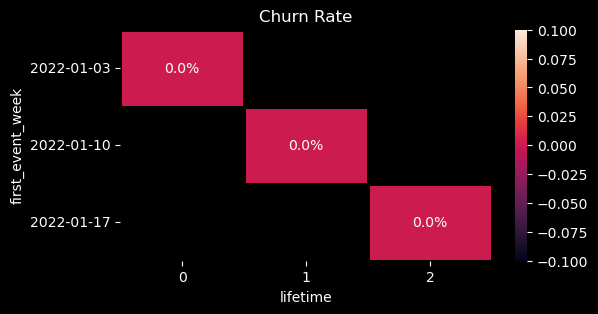

In [18]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Leer datos de churn
cohorts = pd.read_csv("datasets/churn_rate.csv")

# Calcular la tasa de cancelación mediante el cambio porcentual de usuarios
cohorts['churn_rate'] = cohorts.groupby(['first_event_week'])['users_count'].pct_change()

# Crear una tabla pivote para visualizar la tasa de cancelación
churn_pivot = cohorts.pivot_table(index='first_event_week', columns='lifetime', values='churn_rate', aggfunc='sum')

# Configurar la figura y graficar el mapa de calor
plt.figure(figsize=(6, 3))
plt.title('Churn Rate')
sns.heatmap(churn_pivot, annot=True, fmt='.1%', linewidths=1, linecolor='black')
plt.show()

### Cohorte 8: Cohortes comportamentales

#### Concepto teórico:
El análisis de **cohortes comportamentales** se enfoca en segmentar usuarios según su comportamiento. En este caso, se analizan los eventos relacionados con el consumo de café para identificar patrones y determinar si los usuarios muestran un comportamiento objetivo (por ejemplo, consumo frecuente).

#### En este ejercicio:
Se calcula el tiempo transcurrido entre el primer café y cada evento, se filtran aquellos eventos dentro de los primeros 30 días, y se asigna a los usuarios una etiqueta que indica si cumplen con el comportamiento objetivo.

In [52]:
import pandas as pd

# Leer datos de consumo de café
events = pd.read_csv("datasets/coffee_home.csv")

# Convertir las columnas de tiempo a tipo datetime
events['coffee_time'] = pd.to_datetime(events['coffee_time'])
events['first_coffee_datetime'] = pd.to_datetime(events['first_coffee_datetime'])

# Calcular el tiempo transcurrido entre el primer café y cada evento
events['time_to_event'] = events['coffee_time'] - events['first_coffee_datetime']

# Filtrar los eventos que ocurren en menos de 30 días
filtered_events = events[events['time_to_event'] < '30 days']

# Contar el número de eventos por usuario
count_events_by_users = filtered_events.groupby('user_id').agg({'coffee_time': 'count'}).reset_index()
count_events_by_users['is_target_behavior'] = count_events_by_users['coffee_time'] > 4

# Obtener IDs de usuarios que cumplen o no con el comportamiento objetivo
user_ids_with_target_behavior = count_events_by_users.query('is_target_behavior == True')['user_id'].unique()
user_ids_without_target_behavior = count_events_by_users.query('is_target_behavior != True')['user_id'].unique()

# Asignar etiquetas a los usuarios según su comportamiento
events.loc[events['user_id'].isin(user_ids_with_target_behavior), 'is_in_behavioral_cohort'] = 'yes'
events.loc[events['user_id'].isin(user_ids_without_target_behavior), 'is_in_behavioral_cohort'] = 'no'

def printRetentionRate(df):
    # Agrupar los datos por la primera fecha de café y contar el número de usuarios
    cohorts = df.groupby(['first_coffee_datetime'], as_index=False).agg({'user_id': 'nunique'})
    print(cohorts)

printRetentionRate(events[events['is_in_behavioral_cohort'] == 'yes'])

  first_coffee_datetime  user_id
0            2022-01-01        1
1            2022-01-04        2
2            2022-01-05        1
